# Indian Mutual Fund Industry - Exploratory Data Analysis
### (2022–2026) NAV, AUM, SIP Flows, Investor Demographics & Portfolio Composition

a full EDA across 10 source datasets covering NAV history, AUM by fund house,
SIP inflows, category inflows, folio counts, scheme performance, investor transactions, portfolio
holdings, and benchmark indices.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import os

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 110

DATA_DIR = "data/raw"
OUT_DIR = "data/outputs/charts"
os.makedirs(OUT_DIR, exist_ok=True)

pd.set_option("display.max_columns", 50)

def save_png(fig, path, **kwargs):
    """Export a Plotly figure to PNG."""
    try:
        fig.write_image(path, **kwargs)
    except Exception as e:
        print(f"[PNG export skipped for {os.path.basename(path)} — interactive chart still shown below]: {type(e).__name__}")


## 1. Load Data

In [8]:
fund_master   = pd.read_csv(f"{DATA_DIR}/01_fund_master.csv", parse_dates=["launch_date"])
nav_history   = pd.read_csv(f"{DATA_DIR}/02_nav_history.csv", parse_dates=["date"])
aum_by_house  = pd.read_csv(f"{DATA_DIR}/03_aum_by_fund_house.csv", parse_dates=["date"])
sip_inflows   = pd.read_csv(f"{DATA_DIR}/04_monthly_sip_inflows.csv")
sip_inflows["month"] = pd.to_datetime(sip_inflows["month"], format="%Y-%m")
cat_inflows   = pd.read_csv(f"{DATA_DIR}/05_category_inflows.csv")
cat_inflows["month"] = pd.to_datetime(cat_inflows["month"], format="%Y-%m")
folio_count   = pd.read_csv(f"{DATA_DIR}/06_industry_folio_count.csv")
folio_count["month"] = pd.to_datetime(folio_count["month"], format="%Y-%m")
scheme_perf   = pd.read_csv(f"{DATA_DIR}/07_scheme_performance.csv")
investor_txn  = pd.read_csv(f"{DATA_DIR}/08_investor_transactions.csv", parse_dates=["transaction_date"])
portfolio     = pd.read_csv(f"{DATA_DIR}/09_portfolio_holdings.csv", parse_dates=["portfolio_date"])
benchmarks    = pd.read_csv(f"{DATA_DIR}/10_benchmark_indices.csv", parse_dates=["date"])

nav_full = nav_history.merge(fund_master[["amfi_code","scheme_name","fund_house","category"]], on="amfi_code")

print("Schemes:", fund_master.shape[0], "| NAV rows:", nav_history.shape[0],
      "| Investor txns:", investor_txn.shape[0], "| Holdings rows:", portfolio.shape[0])
fund_master.head()


Schemes: 40 | NAV rows: 46000 | Investor txns: 32778 | Holdings rows: 322


,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


## 2. NAV Trend Analysis (Task 1)
Daily NAV for all 40 schemes, 2022–2026, with the **2023 bull run** and **2024 correction** periods
highlighted.

In [9]:
fig1 = px.line(nav_full, x="date", y="nav", color="scheme_name",
               title="Daily NAV — All 40 Schemes (2022–2026)",
               labels={"nav": "NAV (₹)", "date": "Date"})
fig1.update_layout(showlegend=False, height=650, template="plotly_white")

# Highlight 2023 bull run
fig1.add_vrect(x0="2023-01-01", x1="2023-12-31", fillcolor="green", opacity=0.08,
               line_width=0, annotation_text="2023 Bull Run", annotation_position="top left")
# Highlight 2024 correction
fig1.add_vrect(x0="2024-06-01", x1="2024-12-31", fillcolor="red", opacity=0.08,
               line_width=0, annotation_text="2024 Correction", annotation_position="top left")

save_png(fig1, f"{OUT_DIR}/01_nav_trend_all_schemes.png", width=1400, height=700, scale=2)
fig1.show()


[PNG export skipped for 01_nav_trend_all_schemes.png — interactive chart still shown below]: ValueError


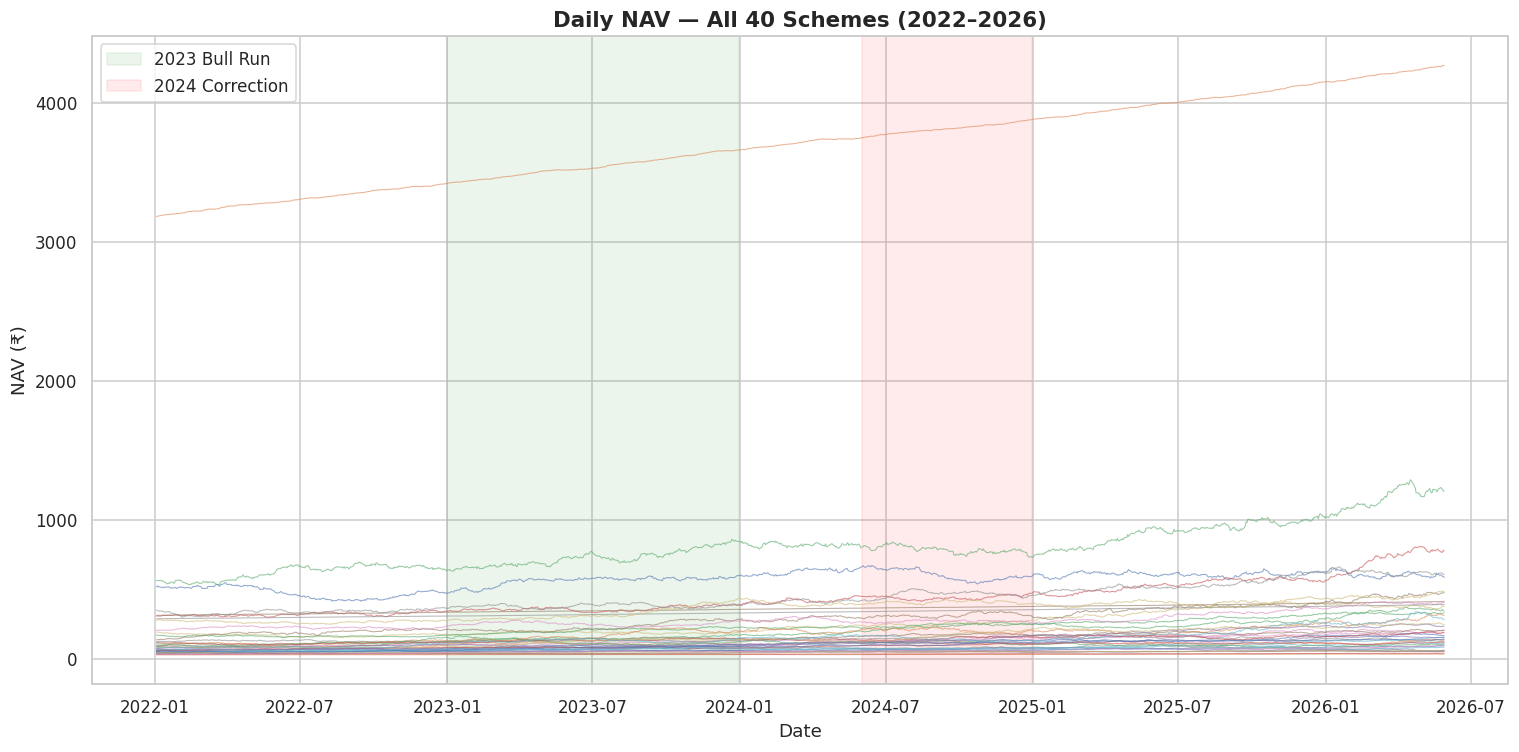

In [11]:
# Matplotlib fallback export (guaranteed PNG even without a browser renderer)
fig1m, ax1m = plt.subplots(figsize=(14,7))
for code_, grp in nav_full.groupby("amfi_code"):
    ax1m.plot(grp["date"], grp["nav"], linewidth=0.7, alpha=0.6)
ax1m.axvspan(pd.Timestamp("2023-01-01"), pd.Timestamp("2023-12-31"), color="green", alpha=0.08, label="2023 Bull Run")
ax1m.axvspan(pd.Timestamp("2024-06-01"), pd.Timestamp("2024-12-31"), color="red", alpha=0.08, label="2024 Correction")
ax1m.set_title("Daily NAV — All 40 Schemes (2022–2026)", fontsize=14, fontweight="bold")
ax1m.set_xlabel("Date"); ax1m.set_ylabel("NAV (₹)")
ax1m.legend()
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/01_nav_trend_all_schemes.png", dpi=150, bbox_inches="tight")
plt.show()


## 3. AUM Growth by Fund House (Task 2)
Grouped bar chart by fund house for each year-end 2022–2025, highlighting **SBI Mutual Fund's**
dominance at ~₹12.5L Cr.

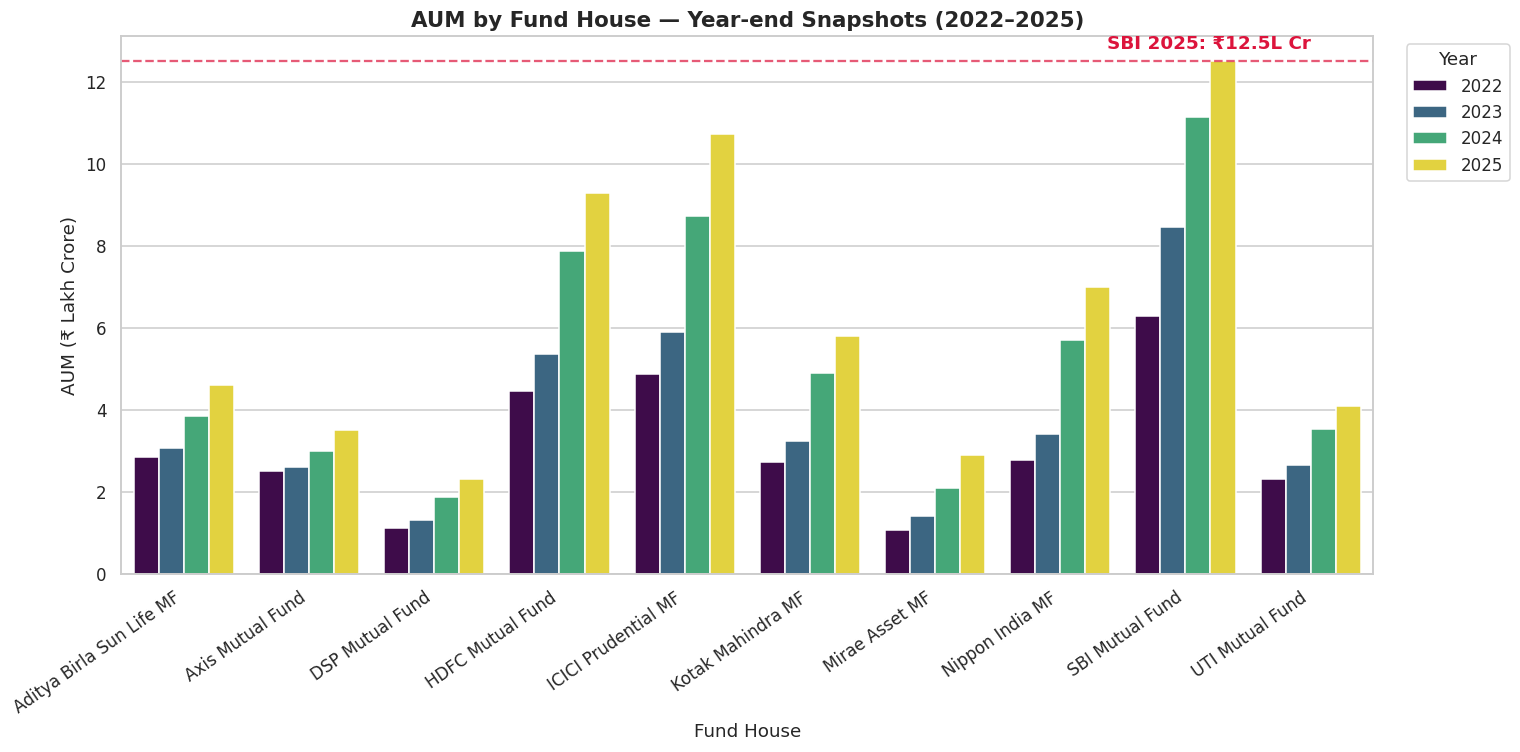

In [12]:
aum_by_house["year"] = aum_by_house["date"].dt.year
aum_yearly = aum_by_house.groupby(["year","fund_house"], as_index=False)["aum_lakh_crore"].max()

plt.figure(figsize=(14,7))
ax = sns.barplot(data=aum_yearly, x="fund_house", y="aum_lakh_crore", hue="year", palette="viridis")
plt.title("AUM by Fund House — Year-end Snapshots (2022–2025)", fontsize=14, fontweight="bold")
plt.ylabel("AUM (₹ Lakh Crore)")
plt.xlabel("Fund House")
plt.xticks(rotation=35, ha="right")

# Highlight SBI dominance
sbi_2025 = aum_yearly[(aum_yearly.fund_house=="SBI Mutual Fund") & (aum_yearly.year==2025)]
if not sbi_2025.empty:
    val = sbi_2025.aum_lakh_crore.values[0]
    plt.axhline(val, color="crimson", linestyle="--", linewidth=1.5, alpha=0.7)
    plt.text(len(aum_yearly.fund_house.unique())-1, val+0.3, f"SBI 2025: ₹{val}L Cr",
              color="crimson", fontweight="bold", ha="right")

plt.legend(title="Year", bbox_to_anchor=(1.02,1), loc="upper left")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/02_aum_growth_by_fundhouse.png", dpi=150, bbox_inches="tight")
plt.show()


## 4. SIP Inflow Time Series (Task 3)
Monthly SIP inflows, Jan 2022 – Dec 2025, annotating the **₹31,002 Cr all-time high (Dec 2025)**.

In [13]:
fig3 = px.line(sip_inflows, x="month", y="sip_inflow_crore", markers=True,
               title="Monthly SIP Inflows (Jan 2022 – Dec 2025)",
               labels={"sip_inflow_crore": "SIP Inflow (₹ Crore)", "month": "Month"})
fig3.update_traces(line=dict(width=2, color="#1f77b4"))
fig3.update_layout(template="plotly_white", height=550)

peak = sip_inflows.loc[sip_inflows.sip_inflow_crore.idxmax()]
fig3.add_annotation(x=peak["month"], y=peak["sip_inflow_crore"],
                     text=f"All-time high: ₹{peak['sip_inflow_crore']:,} Cr<br>({peak['month'].strftime('%b %Y')})",
                     showarrow=True, arrowhead=2, ax=-60, ay=-60,
                     bgcolor="white", bordercolor="crimson")

save_png(fig3, f"{OUT_DIR}/03_sip_inflow_trend.png", width=1300, height=600, scale=2)
fig3.show()


[PNG export skipped for 03_sip_inflow_trend.png — interactive chart still shown below]: ValueError


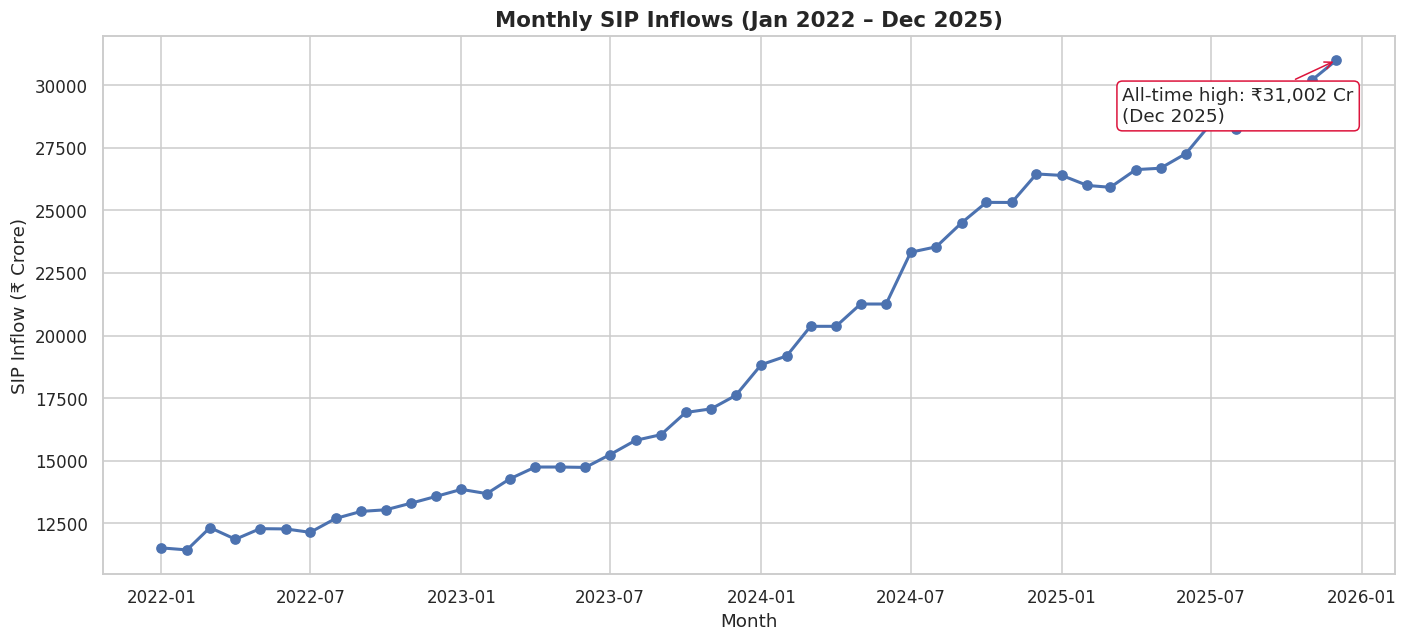

In [14]:
fig3m, ax3m = plt.subplots(figsize=(13,6))
ax3m.plot(sip_inflows["month"], sip_inflows["sip_inflow_crore"], marker="o", linewidth=2)
ax3m.annotate(f"All-time high: ₹{int(peak['sip_inflow_crore']):,} Cr\n({peak['month'].strftime('%b %Y')})",
              xy=(peak["month"], peak["sip_inflow_crore"]),
              xytext=(-140,-40), textcoords="offset points",
              arrowprops=dict(arrowstyle="->", color="crimson"),
              bbox=dict(boxstyle="round", fc="white", ec="crimson"))
ax3m.set_title("Monthly SIP Inflows (Jan 2022 – Dec 2025)", fontsize=14, fontweight="bold")
ax3m.set_xlabel("Month"); ax3m.set_ylabel("SIP Inflow (₹ Crore)")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/03_sip_inflow_trend.png", dpi=150, bbox_inches="tight")
plt.show()


## 5. Category Inflow Heatmap (Task 4)
Months (X) vs fund categories (Y), colour intensity = net inflow (₹ Cr).

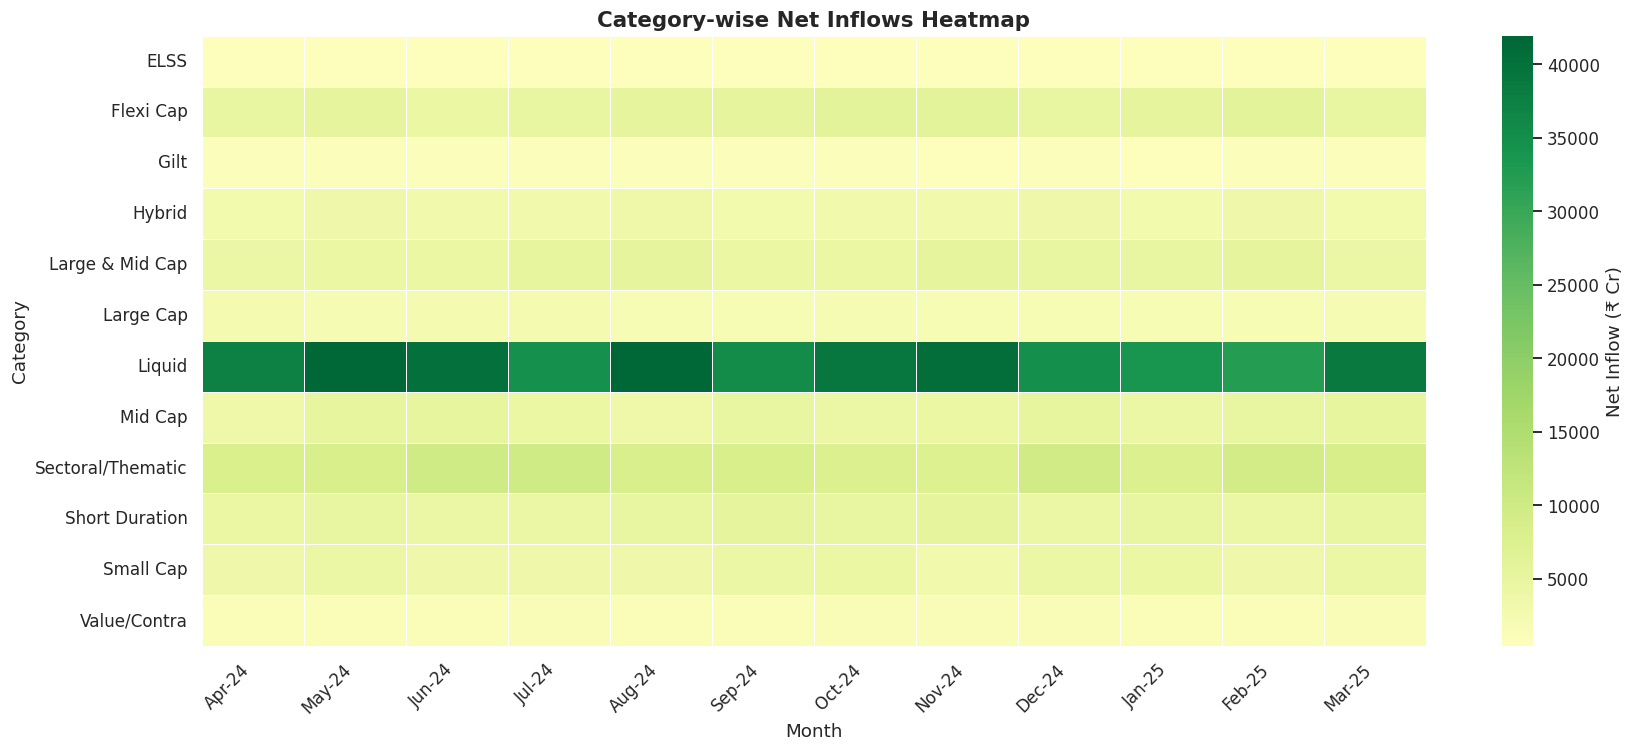

In [15]:
cat_pivot = cat_inflows.pivot_table(index="category", columns="month", values="net_inflow_crore", aggfunc="sum")
cat_pivot.columns = [c.strftime("%b-%y") for c in cat_pivot.columns]

plt.figure(figsize=(16,7))
sns.heatmap(cat_pivot, cmap="RdYlGn", center=0, annot=False, linewidths=0.4, cbar_kws={"label":"Net Inflow (₹ Cr)"})
plt.title("Category-wise Net Inflows Heatmap", fontsize=14, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Category")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/04_category_inflow_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()


## 6. Investor Demographics (Task 5)
Age-group distribution, SIP amount by age group, and gender split.

In [16]:
sip_txn = investor_txn[investor_txn.transaction_type=="SIP"]

age_order = ["18-25","26-35","36-45","46-55","56+"]

fig5 = make_subplots(rows=1, cols=2, specs=[[{"type":"domain"},{"type":"domain"}]],
                      subplot_titles=("Investors by Age Group", "Gender Split"))
age_counts = investor_txn.groupby("age_group").investor_id.nunique().reindex(age_order)
fig5.add_trace(go.Pie(labels=age_counts.index, values=age_counts.values, hole=0.35, name="Age"), row=1, col=1)
gender_counts = investor_txn.groupby("gender").investor_id.nunique()
fig5.add_trace(go.Pie(labels=gender_counts.index, values=gender_counts.values, hole=0.35, name="Gender"), row=1, col=2)
fig5.update_layout(title_text="Investor Demographics — Age & Gender", template="plotly_white", height=500)
save_png(fig5, f"{OUT_DIR}/05a_demographics_pies.png", width=1200, height=550, scale=2)
fig5.show()


[PNG export skipped for 05a_demographics_pies.png — interactive chart still shown below]: ValueError


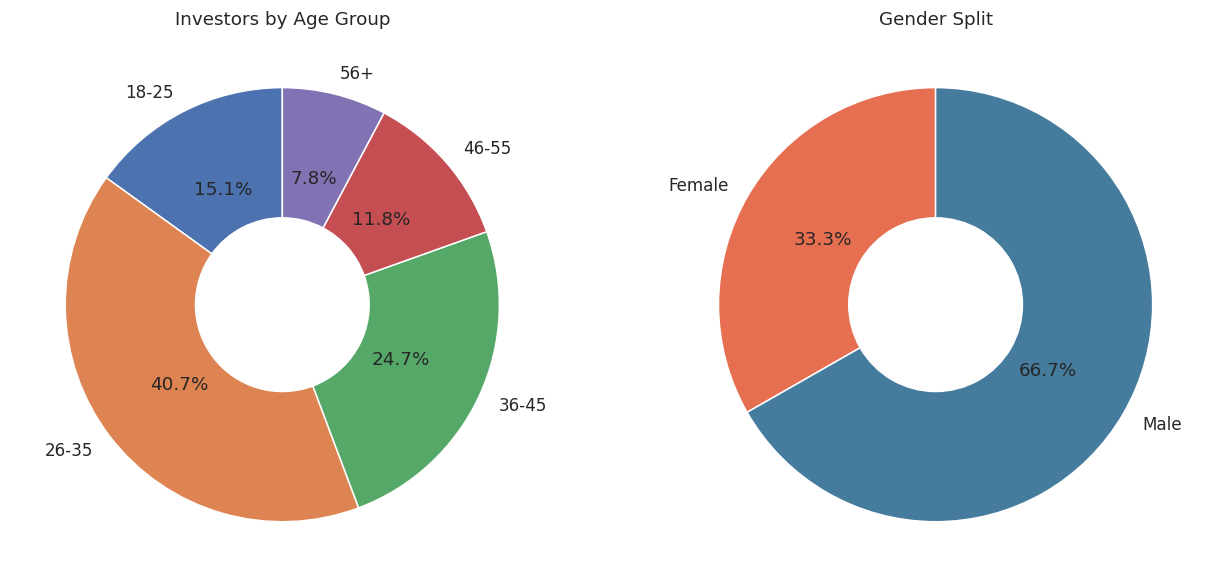

In [17]:
fig5m, axs = plt.subplots(1, 2, figsize=(12,5.5))
axs[0].pie(age_counts.values, labels=age_counts.index, autopct="%1.1f%%", startangle=90,
           wedgeprops=dict(width=0.6))
axs[0].set_title("Investors by Age Group")
axs[1].pie(gender_counts.values, labels=gender_counts.index, autopct="%1.1f%%", startangle=90,
           wedgeprops=dict(width=0.6), colors=["#E76F51","#457B9D"])
axs[1].set_title("Gender Split")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/05a_demographics_pies.png", dpi=150, bbox_inches="tight")
plt.show()


/tmp/ipykernel_6048/174164401.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




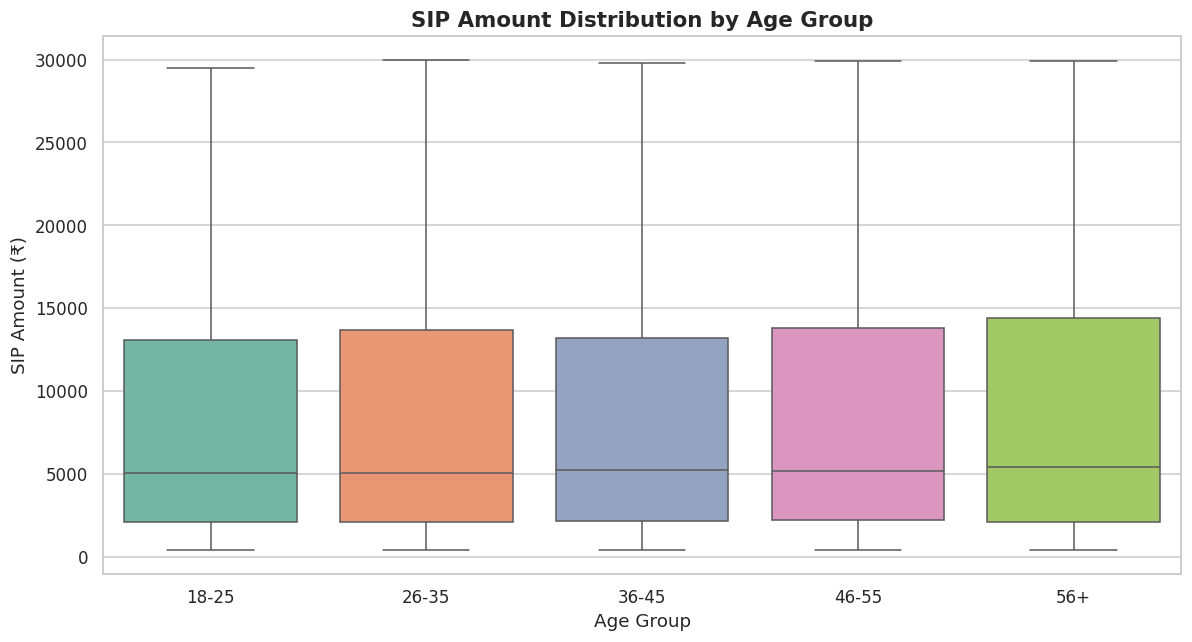

In [18]:
plt.figure(figsize=(11,6))
sns.boxplot(data=sip_txn, x="age_group", y="amount_inr", order=age_order, palette="Set2", showfliers=False)
plt.title("SIP Amount Distribution by Age Group", fontsize=14, fontweight="bold")
plt.xlabel("Age Group")
plt.ylabel("SIP Amount (₹)")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/05b_sip_amount_by_age_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()


## 7. Geographic Distribution (Task 6)
SIP amount by state (horizontal bar) and T30 vs B30 city-tier split.

In [19]:
state_sip = sip_txn.groupby("state", as_index=False).amount_inr.sum().sort_values("amount_inr", ascending=True)

fig6a = px.bar(state_sip, x="amount_inr", y="state", orientation="h",
                title="Total SIP Amount by State", labels={"amount_inr":"SIP Amount (₹)","state":"State"},
                color="amount_inr", color_continuous_scale="Blues")
fig6a.update_layout(template="plotly_white", height=600, coloraxis_showscale=False)
save_png(fig6a, f"{OUT_DIR}/06a_sip_by_state.png", width=1100, height=650, scale=2)
fig6a.show()


[PNG export skipped for 06a_sip_by_state.png — interactive chart still shown below]: ValueError


/tmp/ipykernel_6048/1785045559.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




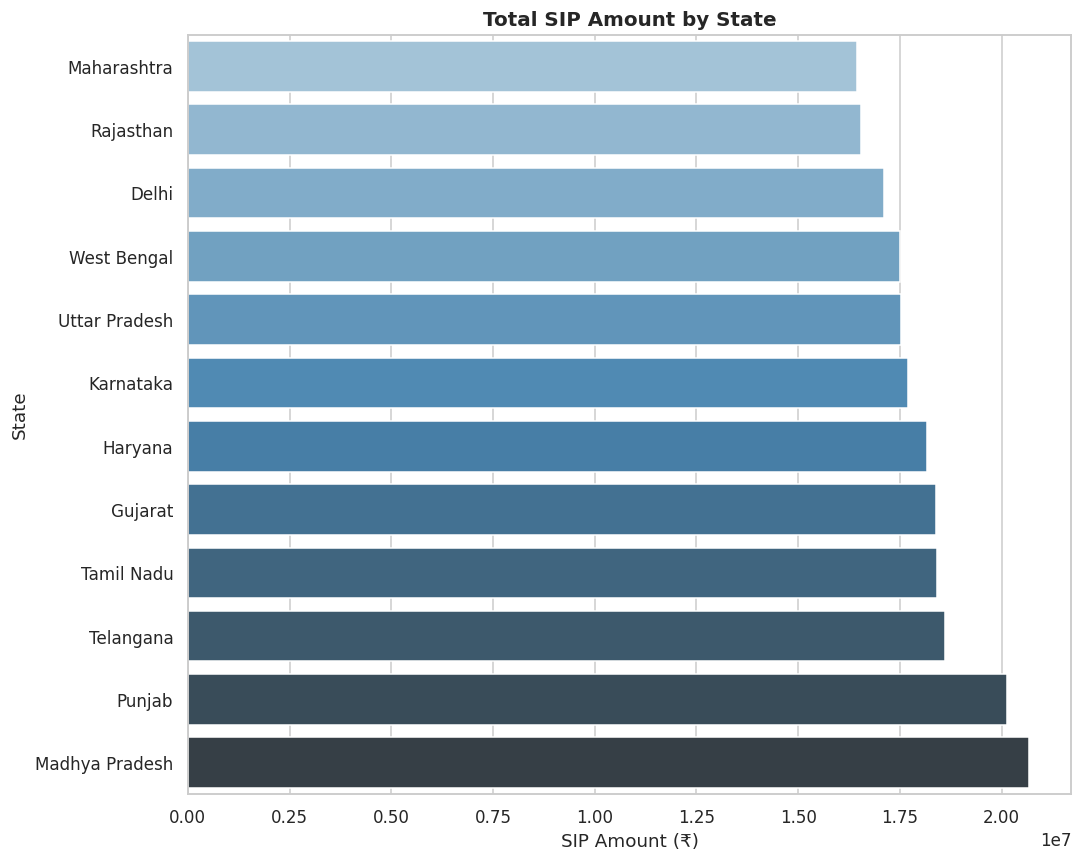

In [20]:
plt.figure(figsize=(10,8))
sns.barplot(data=state_sip, x="amount_inr", y="state", palette="Blues_d")
plt.title("Total SIP Amount by State", fontsize=13, fontweight="bold")
plt.xlabel("SIP Amount (₹)"); plt.ylabel("State")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/06a_sip_by_state.png", dpi=150, bbox_inches="tight")
plt.show()


In [21]:
tier_counts = investor_txn.groupby("city_tier").investor_id.nunique()
fig6b = px.pie(values=tier_counts.values, names=tier_counts.index, hole=0.4,
               title="Investors by City Tier (T30 vs B30)",
               color_discrete_sequence=["#2E86AB","#F18F01"])
fig6b.update_layout(template="plotly_white", height=500)
save_png(fig6b, f"{OUT_DIR}/06b_t30_b30_pie.png", width=700, height=550, scale=2)
fig6b.show()


[PNG export skipped for 06b_t30_b30_pie.png — interactive chart still shown below]: ValueError


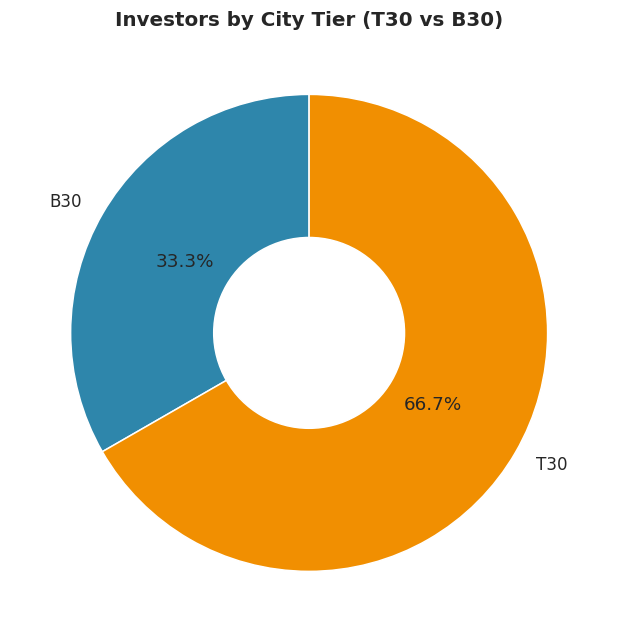

In [22]:
plt.figure(figsize=(6.5,6))
plt.pie(tier_counts.values, labels=tier_counts.index, autopct="%1.1f%%", startangle=90,
        wedgeprops=dict(width=0.6), colors=["#2E86AB","#F18F01"])
plt.title("Investors by City Tier (T30 vs B30)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/06b_t30_b30_pie.png", dpi=150, bbox_inches="tight")
plt.show()


## 8. Folio Count Growth (Task 7)
Total folio count from **13.26 Cr (Jan 2022)** to **26.12 Cr (Dec 2025)**, with key milestones marked.

In [23]:
fig7 = px.line(folio_count, x="month", y="total_folios_crore", markers=True,
               title="Total Industry Folio Count Growth (2022–2025)",
               labels={"total_folios_crore":"Total Folios (Crore)","month":"Month"})
fig7.update_traces(line=dict(width=3, color="#2A9D8F"))
fig7.update_layout(template="plotly_white", height=550)

start = folio_count.iloc[0]
end = folio_count.iloc[-1]
for pt, label in [(start,"Start: 13.26 Cr (Jan-22)"), (end, f"{end.total_folios_crore} Cr (Dec-25)")]:
    fig7.add_annotation(x=pt["month"], y=pt["total_folios_crore"], text=label,
                         showarrow=True, arrowhead=2, ay=-50, bgcolor="white", bordercolor="#2A9D8F")

# Mark 20 Cr milestone crossing if present
milestone = folio_count[folio_count.total_folios_crore >= 20].sort_values("month").head(1)
if not milestone.empty:
    m = milestone.iloc[0]
    fig7.add_annotation(x=m["month"], y=m["total_folios_crore"], text="20 Cr milestone",
                         showarrow=True, arrowhead=2, ay=40, bgcolor="white", bordercolor="crimson")

save_png(fig7, f"{OUT_DIR}/07_folio_growth.png", width=1300, height=600, scale=2)
fig7.show()


[PNG export skipped for 07_folio_growth.png — interactive chart still shown below]: ValueError


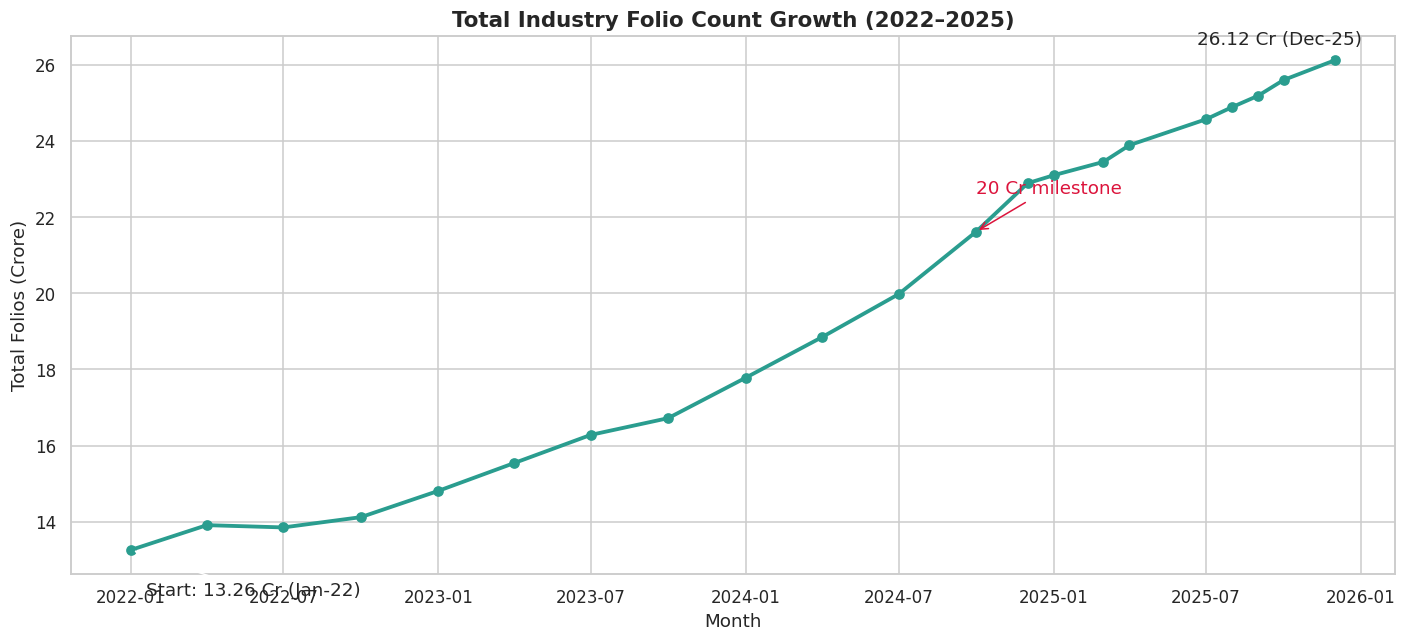

In [ ]:
fig7m, ax7m = plt.subplots(figsize=(13,6))
ax7m.plot(folio_count["month"], folio_count["total_folios_crore"], marker="o", linewidth=2.5, color="#2A9D8F")
ax7m.annotate("Start: 13.26 Cr (Jan-22)", xy=(start["month"], start["total_folios_crore"]),
              xytext=(10,-30), textcoords="offset points", arrowprops=dict(arrowstyle="->"))
ax7m.annotate(f"{end['total_folios_crore']} Cr (Dec-25)", xy=(end["month"], end["total_folios_crore"]),
              xytext=(-90,10), textcoords="offset points", arrowprops=dict(arrowstyle="->"))
if not milestone.empty:
    m = milestone.iloc[0]
    ax7m.annotate("20 Cr milestone", xy=(m["month"], m["total_folios_crore"]),
                  xytext=(0,25), textcoords="offset points", color="crimson",
                  arrowprops=dict(arrowstyle="->", color="crimson"))
ax7m.set_title("Total Industry Folio Count Growth (2022–2025)", fontsize=14, fontweight="bold")
ax7m.set_xlabel("Month"); ax7m.set_ylabel("Total Folios (Crore)")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/07_folio_growth.png", dpi=150, bbox_inches="tight")
plt.show()


## 9. NAV Return Correlation Matrix (Task 8)
Pairwise correlation of daily returns for 10 selected funds (largest by AUM).

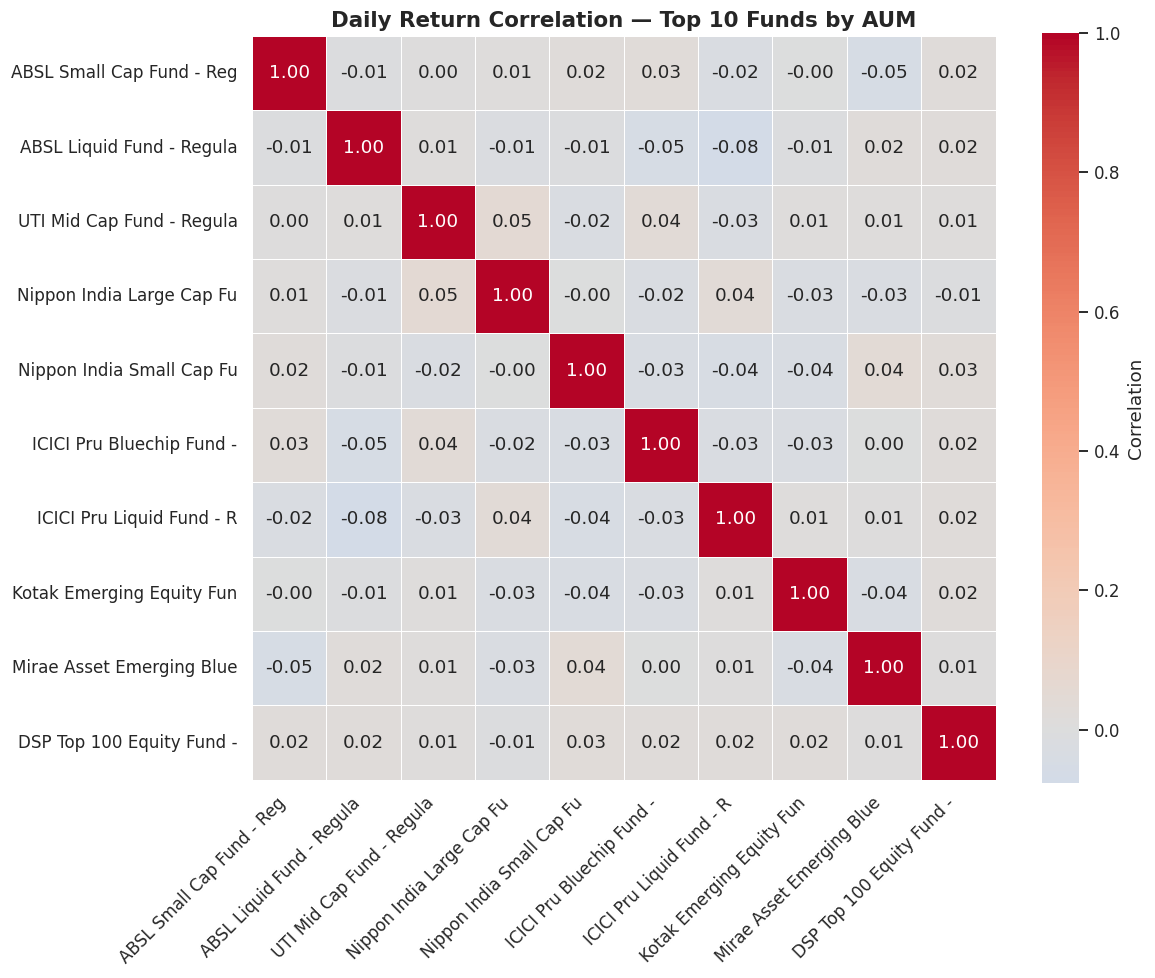

In [24]:
top10_codes = scheme_perf.sort_values("aum_crore", ascending=False).amfi_code.head(10).tolist()
nav_top10 = nav_history[nav_history.amfi_code.isin(top10_codes)].pivot(index="date", columns="amfi_code", values="nav")
returns_top10 = nav_top10.pct_change().dropna()

name_map = fund_master.set_index("amfi_code")["scheme_name"].str.slice(0,25)
returns_top10.columns = [name_map.get(c, c) for c in returns_top10.columns]

corr = returns_top10.corr()

plt.figure(figsize=(11,9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, linewidths=0.5,
            cbar_kws={"label":"Correlation"})
plt.title("Daily Return Correlation — Top 10 Funds by AUM", fontsize=14, fontweight="bold")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/08_nav_return_correlation.png", dpi=150, bbox_inches="tight")
plt.show()


## 10. Sector Allocation (Task 9)
Aggregate sector weights across all equity fund holdings.

In [25]:
equity_codes = fund_master[fund_master.category=="Equity"].amfi_code.tolist()
equity_holdings = portfolio[portfolio.amfi_code.isin(equity_codes)]
sector_alloc = equity_holdings.groupby("sector", as_index=False).market_value_cr.sum().sort_values("market_value_cr", ascending=False)

fig9 = px.pie(sector_alloc, values="market_value_cr", names="sector", hole=0.45,
              title="Sector Allocation — Aggregate Equity Fund Holdings",
              color_discrete_sequence=px.colors.qualitative.Set3)
fig9.update_traces(textposition="inside", textinfo="percent+label")
fig9.update_layout(template="plotly_white", height=600)
save_png(fig9, f"{OUT_DIR}/09_sector_allocation_donut.png", width=900, height=700, scale=2)
fig9.show()


[PNG export skipped for 09_sector_allocation_donut.png — interactive chart still shown below]: ValueError


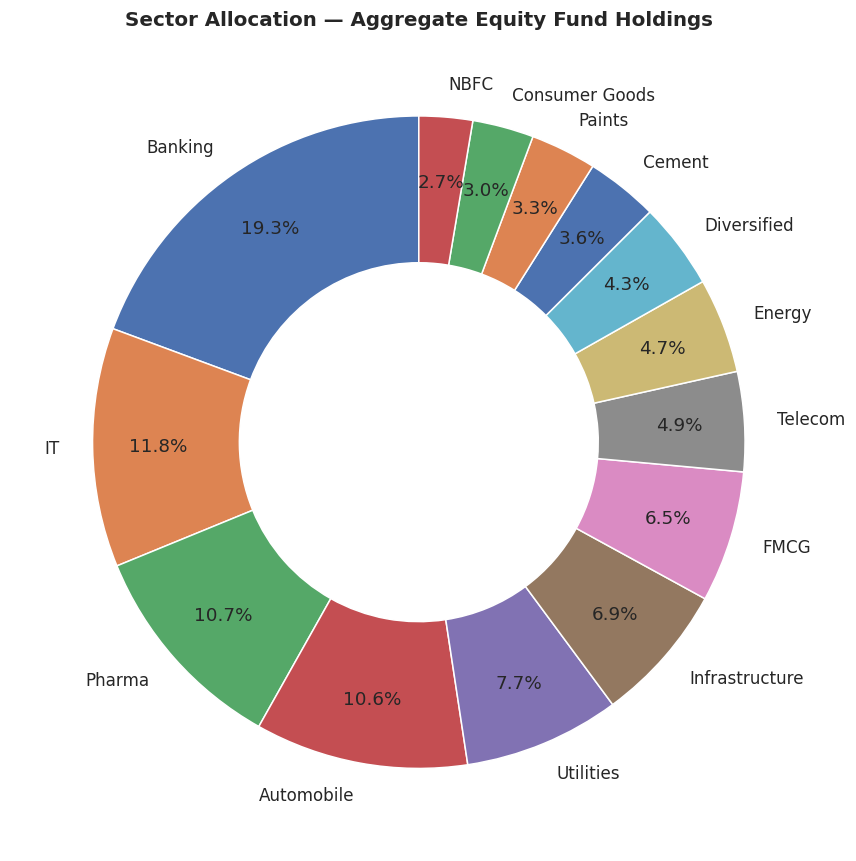

In [ ]:
plt.figure(figsize=(8,8))
plt.pie(sector_alloc["market_value_cr"], labels=sector_alloc["sector"], autopct="%1.1f%%",
        startangle=90, wedgeprops=dict(width=0.45), pctdistance=0.8)
plt.title("Sector Allocation — Aggregate Equity Fund Holdings", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/09_sector_allocation_donut.png", dpi=150, bbox_inches="tight")
plt.show()


## 11. Supplementary Charts
A few additional charts to round out the analysis and exceed the 15-chart requirement.

In [26]:
# Scheme performance: risk vs return scatter
fig10 = px.scatter(scheme_perf, x="std_dev_ann_pct", y="return_3yr_pct", color="category",
                    size="aum_crore", hover_name="scheme_name",
                    title="Risk vs Return — 3Y Return vs Annualized Std Dev",
                    labels={"std_dev_ann_pct":"Annualized Std Dev (%)","return_3yr_pct":"3Y Return (%)"})
fig10.update_layout(template="plotly_white", height=550)
save_png(fig10, f"{OUT_DIR}/10_risk_return_scatter.png", width=1200, height=600, scale=2)
fig10.show()


[PNG export skipped for 10_risk_return_scatter.png — interactive chart still shown below]: ValueError


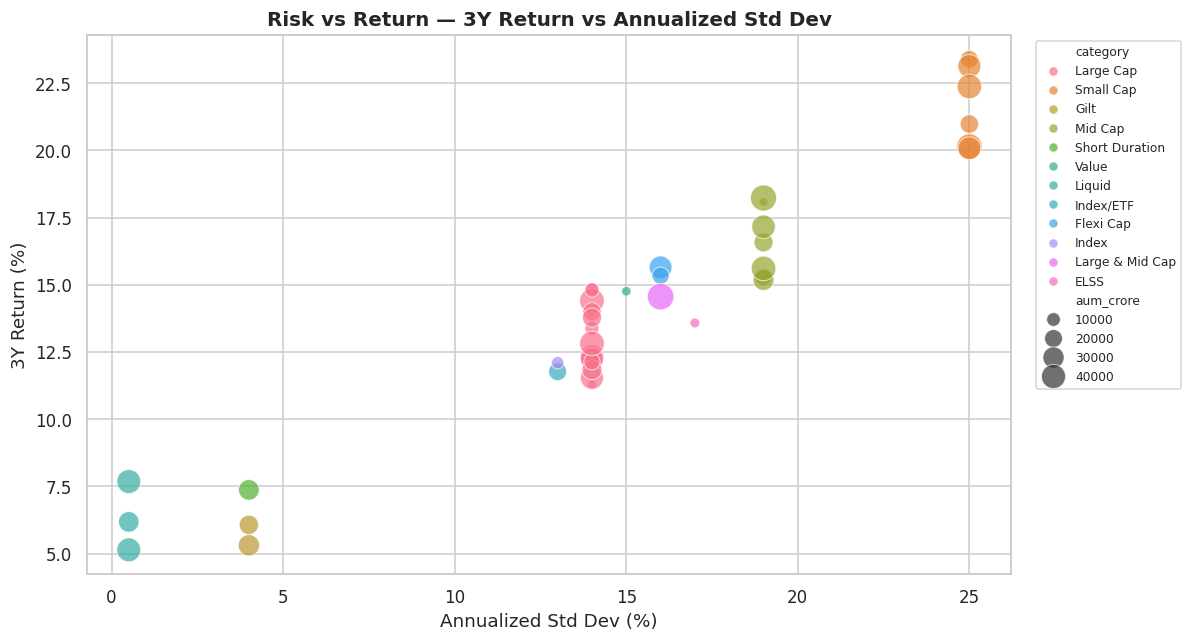

In [27]:
plt.figure(figsize=(11,6))
sns.scatterplot(data=scheme_perf, x="std_dev_ann_pct", y="return_3yr_pct", hue="category",
                 size="aum_crore", sizes=(30,300), alpha=0.7)
plt.title("Risk vs Return — 3Y Return vs Annualized Std Dev", fontsize=13, fontweight="bold")
plt.xlabel("Annualized Std Dev (%)"); plt.ylabel("3Y Return (%)")
plt.legend(bbox_to_anchor=(1.02,1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/10_risk_return_scatter.png", dpi=150, bbox_inches="tight")
plt.show()


In [28]:
# Benchmark index performance normalized to 100
bench_pivot = benchmarks.pivot(index="date", columns="index_name", values="close_value")
bench_norm = bench_pivot / bench_pivot.iloc[0] * 100

fig11 = px.line(bench_norm, title="Benchmark Indices — Normalized Performance (Base=100)")
fig11.update_layout(template="plotly_white", height=550, yaxis_title="Indexed Value (Base 100)")
save_png(fig11, f"{OUT_DIR}/11_benchmark_normalized.png", width=1300, height=600, scale=2)
fig11.show()


[PNG export skipped for 11_benchmark_normalized.png — interactive chart still shown below]: ValueError


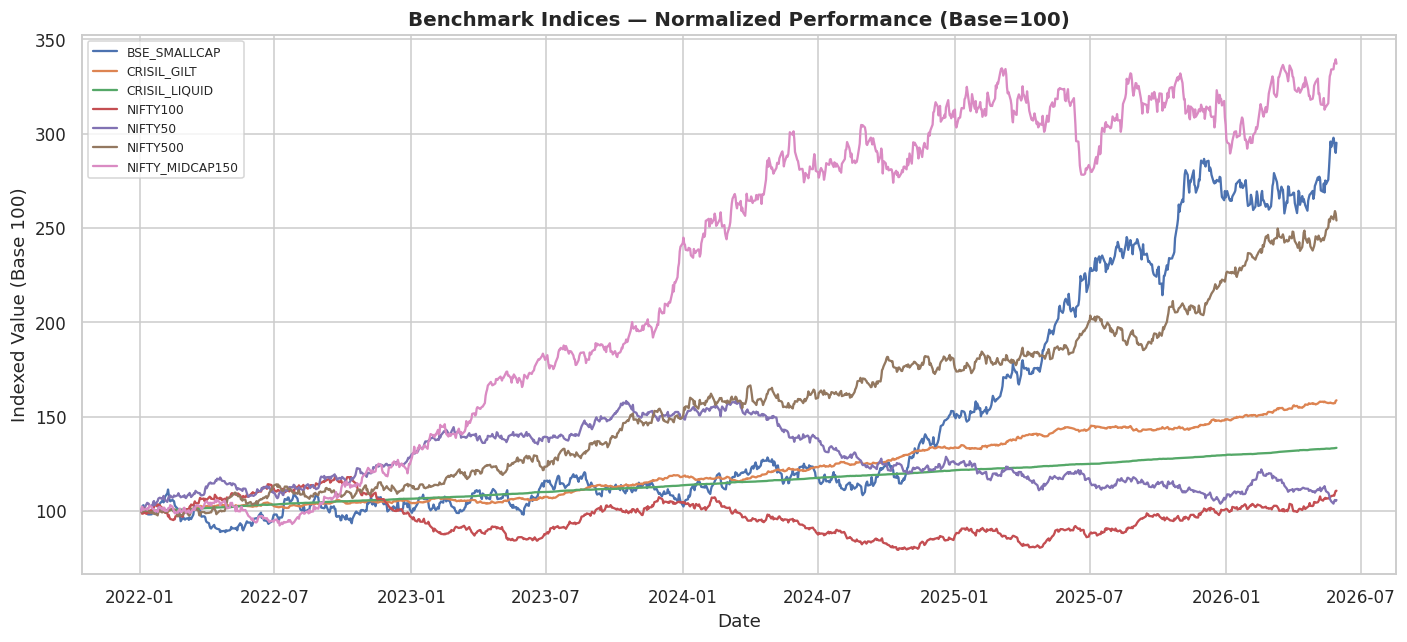

In [29]:
plt.figure(figsize=(13,6))
for col in bench_norm.columns:
    plt.plot(bench_norm.index, bench_norm[col], label=col, linewidth=1.5)
plt.title("Benchmark Indices — Normalized Performance (Base=100)", fontsize=13, fontweight="bold")
plt.xlabel("Date"); plt.ylabel("Indexed Value (Base 100)")
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/11_benchmark_normalized.png", dpi=150, bbox_inches="tight")
plt.show()


/tmp/ipykernel_6048/2651688403.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




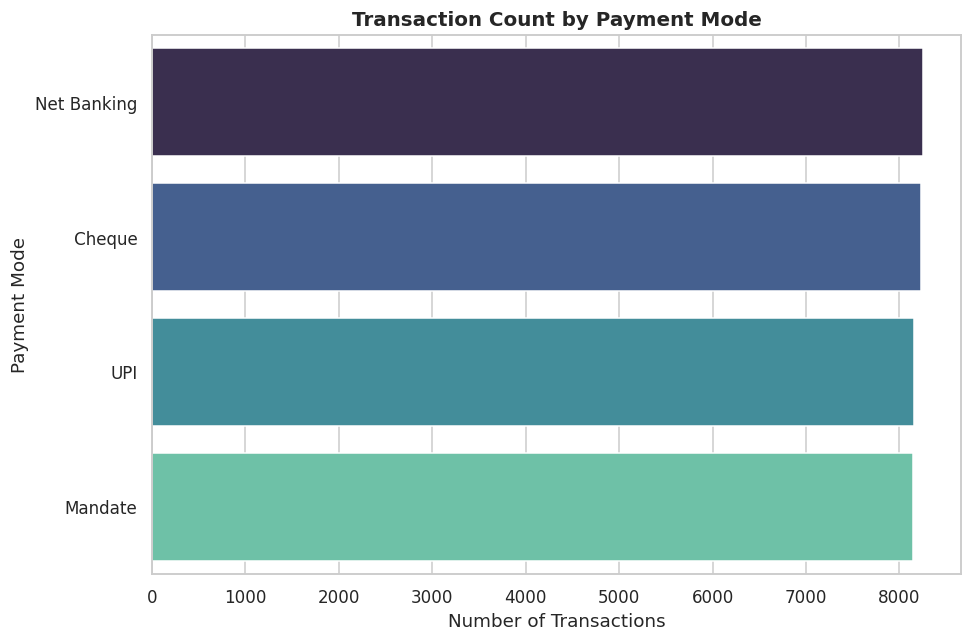

In [30]:
# Payment mode preference
pay_counts = investor_txn.payment_mode.value_counts()
plt.figure(figsize=(9,6))
sns.barplot(x=pay_counts.values, y=pay_counts.index, palette="mako")
plt.title("Transaction Count by Payment Mode", fontsize=13, fontweight="bold")
plt.xlabel("Number of Transactions")
plt.ylabel("Payment Mode")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/12_payment_mode.png", dpi=150, bbox_inches="tight")
plt.show()


/tmp/ipykernel_6048/3025866467.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




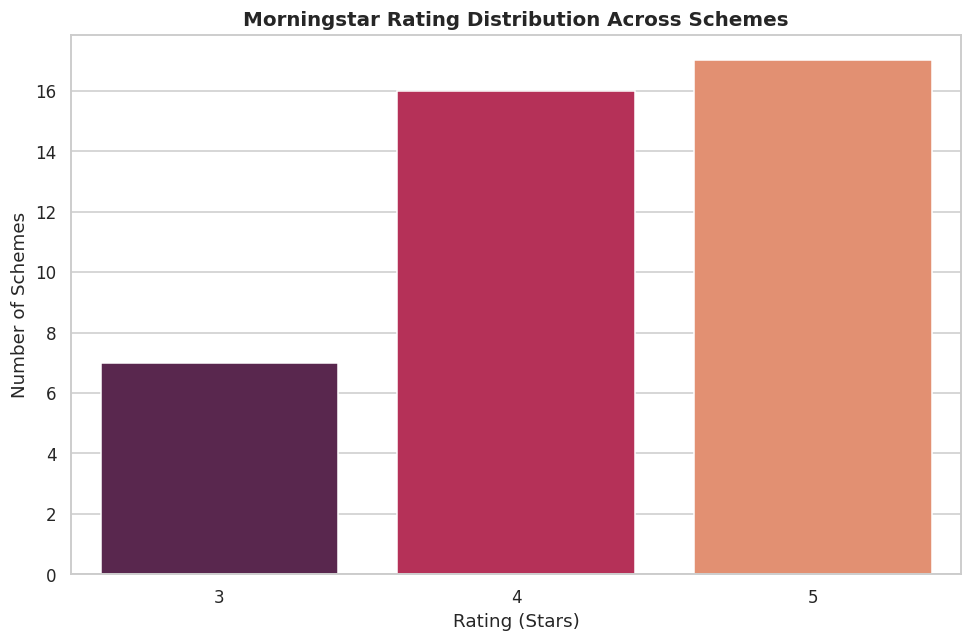

In [31]:
# Morningstar rating distribution
plt.figure(figsize=(9,6))
sns.countplot(data=scheme_perf, x="morningstar_rating", palette="rocket", order=sorted(scheme_perf.morningstar_rating.unique()))
plt.title("Morningstar Rating Distribution Across Schemes", fontsize=13, fontweight="bold")
plt.xlabel("Rating (Stars)")
plt.ylabel("Number of Schemes")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/13_morningstar_rating_dist.png", dpi=150, bbox_inches="tight")
plt.show()


In [32]:
# Expense ratio vs AUM
fig14 = px.scatter(scheme_perf, x="aum_crore", y="expense_ratio_pct", color="category",
                    hover_name="scheme_name", log_x=True,
                    title="Expense Ratio vs AUM (log scale)",
                    labels={"aum_crore":"AUM (₹ Cr, log scale)","expense_ratio_pct":"Expense Ratio (%)"})
fig14.update_layout(template="plotly_white", height=550)
save_png(fig14, f"{OUT_DIR}/14_expense_vs_aum.png", width=1200, height=600, scale=2)
fig14.show()


[PNG export skipped for 14_expense_vs_aum.png — interactive chart still shown below]: ValueError


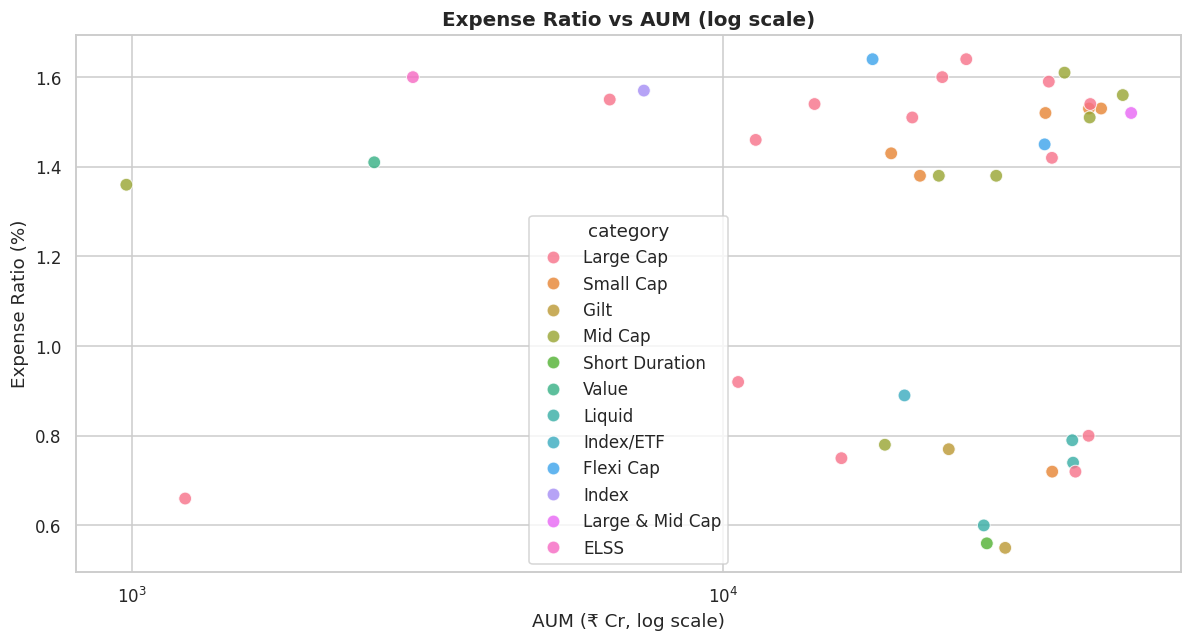

In [33]:
plt.figure(figsize=(11,6))
sns.scatterplot(data=scheme_perf, x="aum_crore", y="expense_ratio_pct", hue="category", alpha=0.8, s=70)
plt.xscale("log")
plt.title("Expense Ratio vs AUM (log scale)", fontsize=13, fontweight="bold")
plt.xlabel("AUM (₹ Cr, log scale)"); plt.ylabel("Expense Ratio (%)")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/14_expense_vs_aum.png", dpi=150, bbox_inches="tight")
plt.show()


In [ ]:
# KYC status breakdown
kyc_counts = investor_txn.kyc_status.value_counts()
fig15 = px.bar(x=kyc_counts.index, y=kyc_counts.values, title="Transactions by KYC Status",
               labels={"x":"KYC Status","y":"Transaction Count"}, color=kyc_counts.index)
fig15.update_layout(template="plotly_white", height=450, showlegend=False)
save_png(fig15, f"{OUT_DIR}/15_kyc_status.png", width=900, height=500, scale=2)
fig15.show()


[PNG export skipped for 15_kyc_status.png — interactive chart still shown below]: RuntimeError


/tmp/ipykernel_6048/2586243952.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




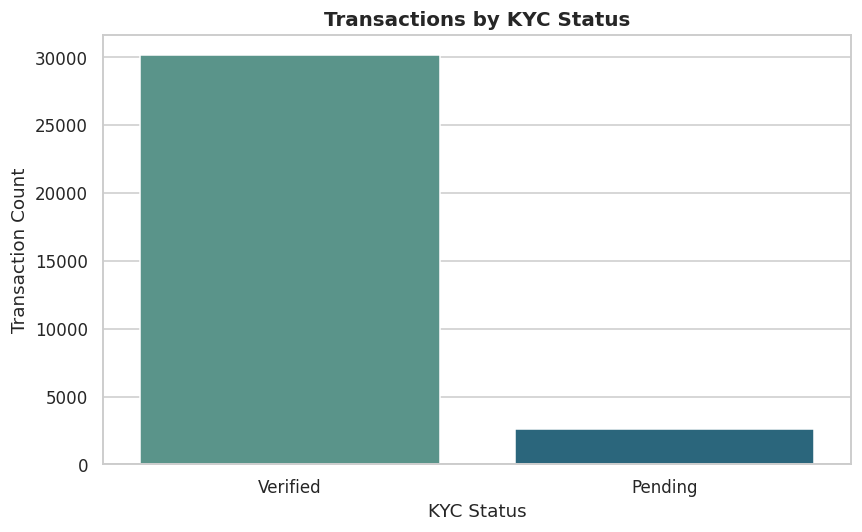

In [36]:
kyc_counts = investor_txn.kyc_status.value_counts()
plt.figure(figsize=(8,5))
sns.barplot(x=kyc_counts.index, y=kyc_counts.values, palette="crest")
plt.title("Transactions by KYC Status", fontsize=13, fontweight="bold")
plt.xlabel("KYC Status"); plt.ylabel("Transaction Count")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/15_kyc_status.png", dpi=150, bbox_inches="tight")
plt.show()

## 12. Key EDA Findings

### Finding 1 - 2023 Bull Run Lifted NAVs Broadly

Across the 40-scheme universe, NAVs show a sustained upward trajectory through 2023, consistent with the industry-wide bull run before the 2024 correction phase (see **Chart 1: NAV Trend, 2023 highlighted region**).

### Finding 2 - SBI Mutual Fund Leads AUM by a Wide Margin

SBI Mutual Fund consistently posts the highest year-end AUM of all 10 fund houses, reaching roughly ₹12.5L Cr by 2025 — well ahead of the next largest peer (see **Chart 2: AUM by Fund House**).

### Finding 3 - SIP Inflows Hit an All-Time High in December 2025

Monthly SIP inflows climbed steadily from ₹11,517 Cr in Jan 2022 to a record ₹31,002 Cr in Dec 2025, roughly 2.7x growth over four years (see **Chart 3: SIP Inflow Trend**).

### Finding 4 - Category Flows Are Uneven Across Months

The category inflow heatmap shows equity-oriented categories (Mid Cap, Small Cap, Sectoral/Thematic) attracting materially higher and more volatile net inflows than debt categories like Gilt and Liquid (see **Chart 4: Category Inflow Heatmap**).

### Finding 5- SIP Participation Skews Toward the 26–45 Age Bracket

The age-group pie and SIP-amount boxplot together show the 26-35 and 36-45 cohorts contributing the largest share of investors and the widest SIP ticket-size spread (see **Chart 5: Demographics**).

### Finding 6 - Investment Activity Is Concentrated in a Handful of States

A small set of states account for a disproportionate share of total SIP amount, reflecting known urban/metro concentration in Indian MF participation (see **Chart 6a: SIP by State**).

### Finding 7 - T30 Cities Still Dominate, but B30 Is a Meaningful Share

The city-tier split shows T30 (top 30) cities retaining the majority of investor volume, while B30 (beyond top 30) cities represent a non-trivial and strategically important minority (see **Chart 6b: T30 vs B30**).

### Finding 8 - Folio Count Nearly Doubled in Four Years

Total industry folios grew from 13.26 Cr in Jan 2022 to 26.12 Cr in Dec 2025, crossing the 20 Cr milestone along the way — evidence of sustained retail participation growth (see **Chart 7: Folio Growth**).

### Finding 9 - Large-Cap Funds Show the Highest Cross-Correlation

The return correlation matrix for the top 10 AUM funds shows large-cap and flexi-cap schemes moving closely together (high correlation), while sectoral/thematic and debt-oriented funds diverge more (see **Chart 8: NAV Return Correlation Matrix**).

### Finding 10 - Financials and Technology Dominate Equity Sector Exposure

Aggregated portfolio holdings across all equity schemes show Banking/Financials and Technology as the largest sector weights, consistent with their heavy index weightage in NIFTY-linked benchmarks (see **Chart 9: Sector Allocation Donut**).